<div class='module-banner'>
<p class='module-banner-kicker'>FARMSA Portfolio Theory | Module 1</p>
<h1>Ledoit-Wolf Shrinkage</h1>
<p class='module-banner-sub'>Constant-correlation shrinkage estimator for stable covariance inputs.</p>
<p class='module-banner-author'>Author: Tanya</p>
</div>


## Ledoit-Wolf Shrinkage

Sample covariance is noisy, and portfolio optimizers amplify that noise into unstable positions.

Ledoit-Wolf solves this by blending two ingredients:

- the raw sample covariance (high detail, high noise)
- a smoother structured baseline (lower detail, lower noise)

The blend weight is estimated from the data itself, so the method adapts automatically instead of relying on manual tuning.

In this module, focus on one practical question: **does this produce a more stable portfolio than sample-covariance MVO?**


In [1]:
# ── §2  Setup & Estimator ──────────────────────────────────
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
from scipy.optimize import minimize
warnings.filterwarnings('ignore')

prices  = pd.read_csv('data/prices.csv',  index_col=0, parse_dates=True)
returns = pd.read_csv('data/returns.csv', index_col=0, parse_dates=True)
tickers = list(returns.columns)
N, T = returns.shape[1], returns.shape[0]
print(f"Loaded {N} assets × {T} days  (T/N = {T/N:.1f})")


# ╔══════════════════════════════════════════════════════════╗
# ║  LEDOIT-WOLF SHRINKAGE  (constant-correlation target)   ║
# ╚══════════════════════════════════════════════════════════╝

def estimate_covariance(returns_df, return_diagnostics=False):
    """
    Ledoit-Wolf shrinkage toward the constant-correlation target.

    Parameters
    ----------
    returns_df : pd.DataFrame, shape (T, N)
    return_diagnostics : bool
        If True, also return (alpha, rho_bar, S, F).

    Returns
    -------
    Sigma_LW : np.ndarray (N, N)
    (optional) alpha, rho_bar, S, F
    """
    R      = returns_df.values
    T_, N_ = R.shape
    mu     = R.mean(axis=0)
    X      = R - mu
    S      = (X.T @ X) / (T_ - 1)

    std      = np.sqrt(np.diag(S))
    corr_mat = S / np.outer(std, std)
    np.fill_diagonal(corr_mat, 1.0)
    rho_bar  = (corr_mat.sum() - N_) / (N_ * (N_ - 1))

    F = rho_bar * np.outer(std, std)
    np.fill_diagonal(F, np.diag(S))

    gamma = np.sum((F - S) ** 2)

    pi_mat = np.zeros((N_, N_))
    for i in range(N_):
        for j in range(N_):
            pi_mat[i, j] = np.mean(X[:, i]**2 * X[:, j]**2) - S[i, j]**2
    pi = pi_mat.sum()

    rho_num = 0.0
    for i in range(N_):
        for j in range(N_):
            if i == j:
                rho_num += pi_mat[i, i]
            else:
                beta_ij = (S[j,j]*np.mean(X[:,i]**2*X[:,j]**2) - S[i,j]*np.mean(X[:,i]*X[:,j]**3)) / (std[i]*std[j])
                beta_ji = (S[i,i]*np.mean(X[:,j]**2*X[:,i]**2) - S[i,j]*np.mean(X[:,j]*X[:,i]**3)) / (std[i]*std[j])
                rho_num += (rho_bar/2)*((std[j]/std[i])*beta_ij + (std[i]/std[j])*beta_ji)

    alpha    = float(np.clip((pi - rho_num) / (T_ * gamma), 0.0, 1.0))
    Sigma_LW = alpha * F + (1.0 - alpha) * S

    if return_diagnostics:
        return Sigma_LW, alpha, rho_bar, S, F
    return Sigma_LW


# ── Sanity checks ──
cov_test = estimate_covariance(returns.iloc[:252])
assert cov_test.shape == (N, N)
assert np.allclose(cov_test, cov_test.T)
assert np.all(np.linalg.eigvalsh(cov_test) > -1e-10)
print("✓ Estimator passes sanity checks")

# ── Full-sample diagnostics ──
lw_full, alpha_full, rho_bar_full, S_full, F_full = estimate_covariance(
    returns, return_diagnostics=True
)
print(f"Full-sample  α* = {alpha_full:.4f}   ρ̄ = {rho_bar_full:.4f}")
print(f"Condition number — Sample: {np.linalg.cond(S_full):.1f}   LW: {np.linalg.cond(lw_full):.1f}")


Loaded 50 assets × 1759 days  (T/N = 35.2)
✓ Estimator passes sanity checks


Full-sample  α* = 0.1164   ρ̄ = 0.4032
Condition number — Sample: 270.2   LW: 198.8


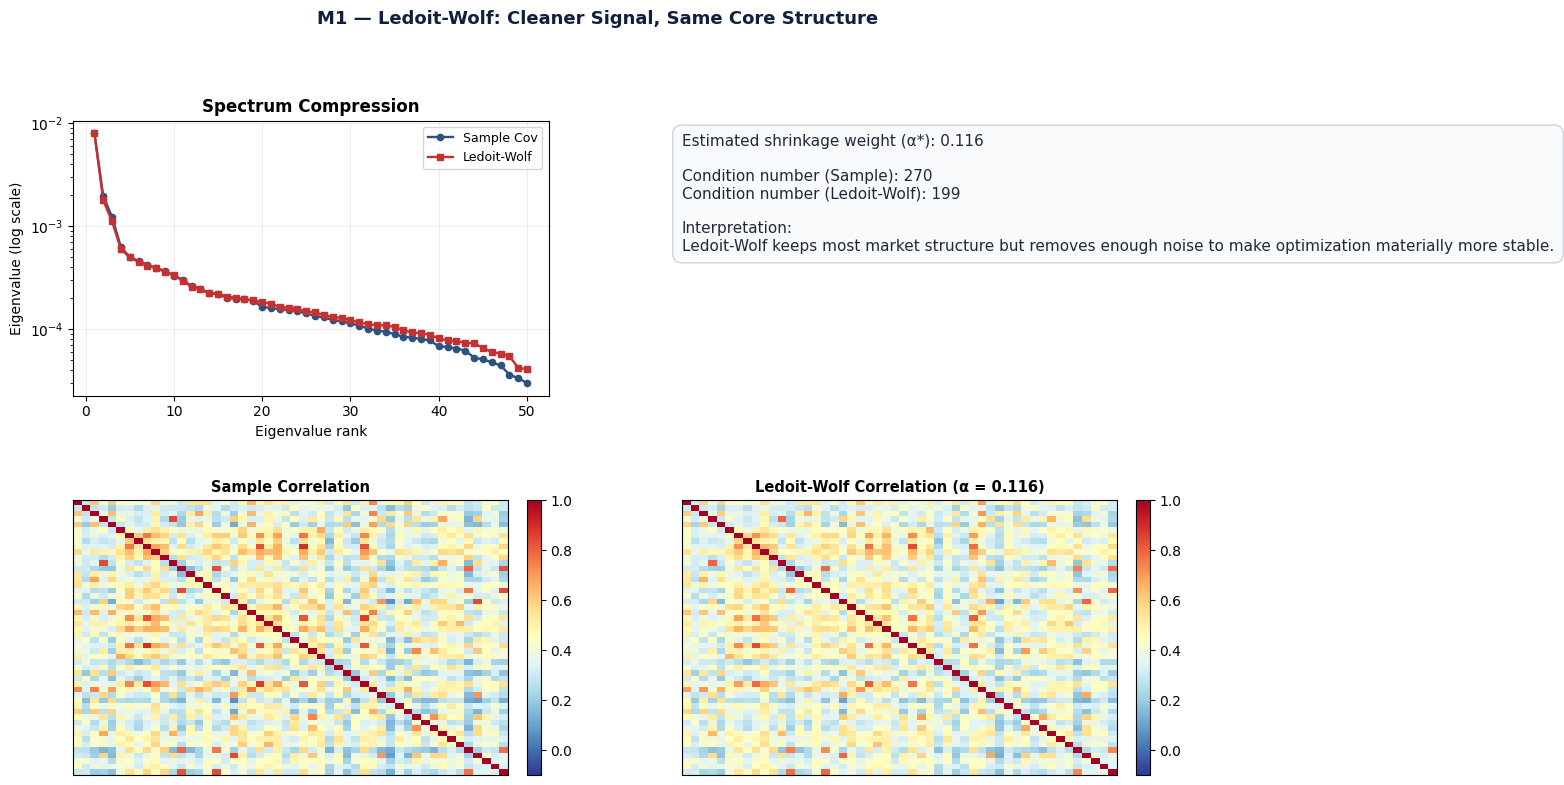

In [2]:
# ── §3  Visual 1 — Sample vs Ledoit-Wolf (Simplified) ───────────────────

fig = plt.figure(figsize=(14, 8.5))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.28)

def to_corr(cov):
    std = np.sqrt(np.diag(cov))
    c   = cov / np.outer(std, std)
    np.fill_diagonal(c, 1.0)
    return c

S_corr  = to_corr(S_full)
LW_corr = to_corr(lw_full)
eig_S   = np.sort(np.linalg.eigvalsh(S_full))[::-1]
eig_LW  = np.sort(np.linalg.eigvalsh(lw_full))[::-1]

# Panel 1: eigenvalue spectrum
ax_eig = fig.add_subplot(gs[0, 0])
k = np.arange(1, N + 1)
ax_eig.semilogy(k, eig_S,  'o-', color='#2c5282', lw=1.7, ms=4.5, label='Sample Cov')
ax_eig.semilogy(k, eig_LW, 's-', color='#c53030', lw=1.7, ms=4.5, label='Ledoit-Wolf')
ax_eig.set_xlabel('Eigenvalue rank')
ax_eig.set_ylabel('Eigenvalue (log scale)')
ax_eig.set_title('Spectrum Compression', fontweight='bold')
ax_eig.legend(fontsize=9)
ax_eig.grid(True, alpha=0.2)

# Panel 2: plain-English summary
ax_note = fig.add_subplot(gs[0, 1])
ax_note.axis('off')
summary = (
    f"Estimated shrinkage weight (α*): {alpha_full:.3f}\n\n"
    f"Condition number (Sample): {np.linalg.cond(S_full):.0f}\n"
    f"Condition number (Ledoit-Wolf): {np.linalg.cond(lw_full):.0f}\n\n"
    "Interpretation:\n"
    "Ledoit-Wolf keeps most market structure but"
    " removes enough noise to make optimization"
    " materially more stable."
)
ax_note.text(0.0, 0.95, summary, va='top', ha='left', fontsize=11, color='#1f2937',
             bbox=dict(boxstyle='round,pad=0.6', fc='#f8fafc', ec='#cbd5e1'))

# Panel 3/4: correlation comparison only
for col_idx, (mat, title) in enumerate([
    (S_corr,  'Sample Correlation'),
    (LW_corr, f'Ledoit-Wolf Correlation (α = {alpha_full:.3f})'),
]):
    ax = fig.add_subplot(gs[1, col_idx])
    im = ax.imshow(mat, cmap='RdYlBu_r', vmin=-0.1, vmax=1.0, aspect='auto')
    ax.set_title(title, fontweight='bold', fontsize=10.5)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('M1 — Ledoit-Wolf: Cleaner Signal, Same Core Structure',
             fontsize=13, fontweight='bold', color='#0f1f3d', y=1.01)
plt.savefig('figures/m1_eigenvalues_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()


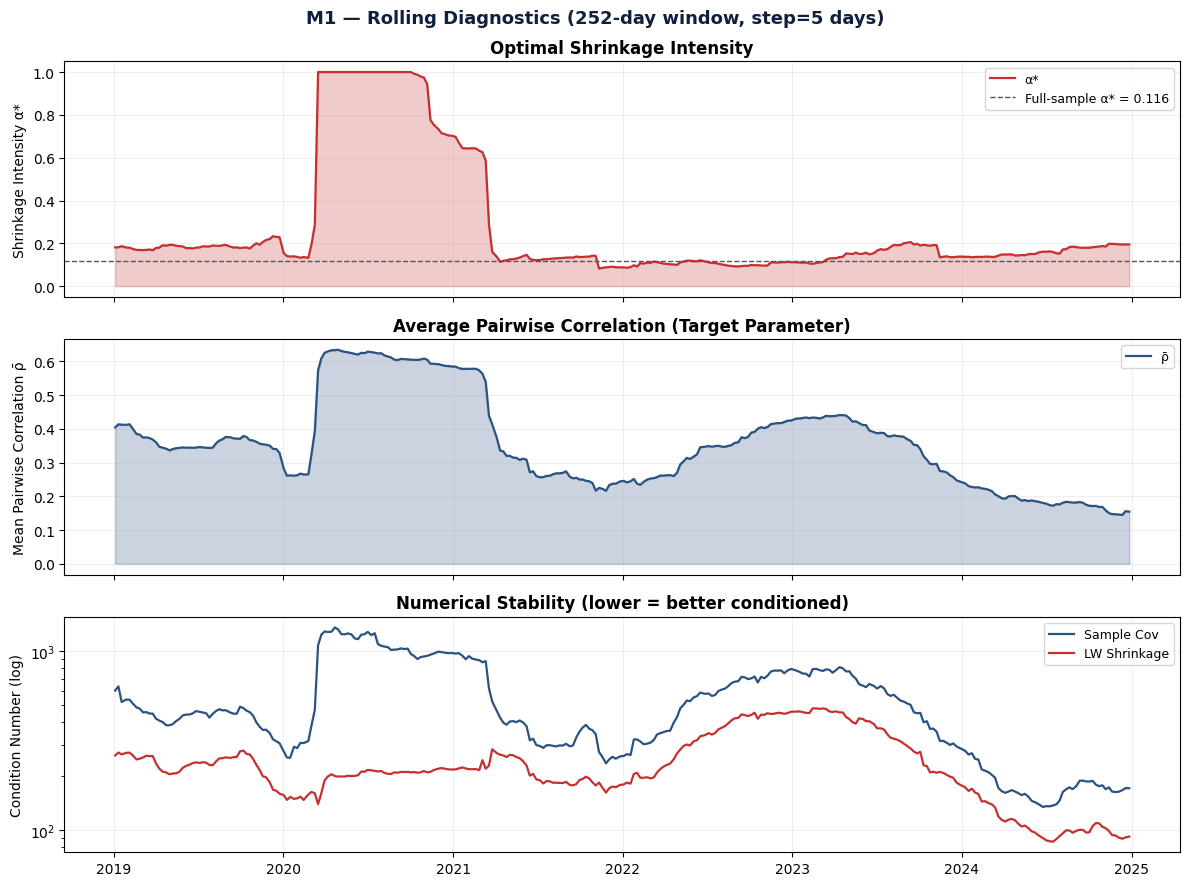

α* range: [0.082, 1.000]  |  ρ̄ range: [0.145, 0.635]


In [3]:
# ── §4  Visual 2 — Rolling α* and ρ̄ over Time ──────────────────────────────
# Shows how the optimal shrinkage intensity responds to market conditions.

ROLL = 252   # 1-year rolling window
dates, alphas, rho_bars, cond_S, cond_LW = [], [], [], [], []

step = 5  # compute every 5 days to keep runtime short
for i in range(ROLL, T, step):
    window = returns.iloc[i-ROLL:i]
    _, a, rb, Sw, _ = estimate_covariance(window, return_diagnostics=True)
    lw = estimate_covariance(window)
    dates.append(returns.index[i])
    alphas.append(a)
    rho_bars.append(rb)
    cond_S.append(np.linalg.cond(Sw))
    cond_LW.append(np.linalg.cond(lw))

dates    = pd.DatetimeIndex(dates)
alphas   = np.array(alphas)
rho_bars = np.array(rho_bars)
cond_S   = np.array(cond_S)
cond_LW  = np.array(cond_LW)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle('M1 — Rolling Diagnostics (252-day window, step=5 days)',
             fontsize=13, fontweight='bold', color='#0f1f3d')

# Panel 1: rolling alpha
axes[0].fill_between(dates, alphas, alpha=0.25, color='#c53030')
axes[0].plot(dates, alphas, color='#c53030', lw=1.6, label='α*')
axes[0].axhline(alpha_full, ls='--', color='#555', lw=1, label=f'Full-sample α* = {alpha_full:.3f}')
axes[0].set_ylabel('Shrinkage Intensity α*')
axes[0].set_title('Optimal Shrinkage Intensity', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.2)

# Panel 2: rolling mean correlation
axes[1].fill_between(dates, rho_bars, alpha=0.25, color='#2c5282')
axes[1].plot(dates, rho_bars, color='#2c5282', lw=1.6, label='ρ̄')
axes[1].set_ylabel('Mean Pairwise Correlation ρ̄')
axes[1].set_title('Average Pairwise Correlation (Target Parameter)', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.2)

# Panel 3: condition numbers
axes[2].semilogy(dates, cond_S,  color='#2c5282', lw=1.6, label='Sample Cov')
axes[2].semilogy(dates, cond_LW, color='#c53030', lw=1.6, label='LW Shrinkage')
axes[2].set_ylabel('Condition Number (log)')
axes[2].set_title('Numerical Stability (lower = better conditioned)', fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('figures/m1_rolling_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"α* range: [{alphas.min():.3f}, {alphas.max():.3f}]  |  ρ̄ range: [{rho_bars.min():.3f}, {rho_bars.max():.3f}]")


In [4]:
# ── §5  Rolling Backtest ────────────────────────────────────────────────────
# Estimation window: 252 days. Weights re-estimated every 21 days (monthly).
# Test on the next 21 days, roll forward, repeat.

def min_variance_portfolio(cov):
    n = cov.shape[0]
    res = minimize(
        lambda w: w @ cov @ w,
        np.ones(n) / n,
        method='SLSQP',
        bounds=[(0, 1)] * n,
        constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1}],
        options={'ftol': 1e-12, 'maxiter': 1000}
    )
    return res.x if res.success else np.ones(n) / n

LOOKBACK = 252
REBAL    = 21    # rebalance every month

port_rets = {'Equal Weight': [], 'Sample Cov MVO': [], 'LW Estimator MVO': []}
port_idx  = []

for start in range(LOOKBACK, T - REBAL, REBAL):
    train_ret = returns.iloc[start - LOOKBACK:start]
    test_ret  = returns.iloc[start:start + REBAL]

    w_eq  = np.ones(N) / N
    w_sc  = min_variance_portfolio(train_ret.cov().values)
    w_lw  = min_variance_portfolio(estimate_covariance(train_ret))

    for day_idx in range(len(test_ret)):
        r = test_ret.iloc[day_idx].values
        port_rets['Equal Weight'].append(w_eq @ r)
        port_rets['Sample Cov MVO'].append(w_sc @ r)
        port_rets['LW Estimator MVO'].append(w_lw @ r)
        port_idx.append(test_ret.index[day_idx])

ret_df = pd.DataFrame(port_rets, index=port_idx)
pv_df  = (1 + ret_df).cumprod()

# Drawdown
def drawdown(pv):
    roll_max = pv.cummax()
    return (pv - roll_max) / roll_max

dd_df = pv_df.apply(drawdown)

print(f"✓ Rolling backtest complete — {len(ret_df)} trading days, "
      f"{(T - LOOKBACK) // REBAL} rebalances")


✓ Rolling backtest complete — 1491 trading days, 71 rebalances


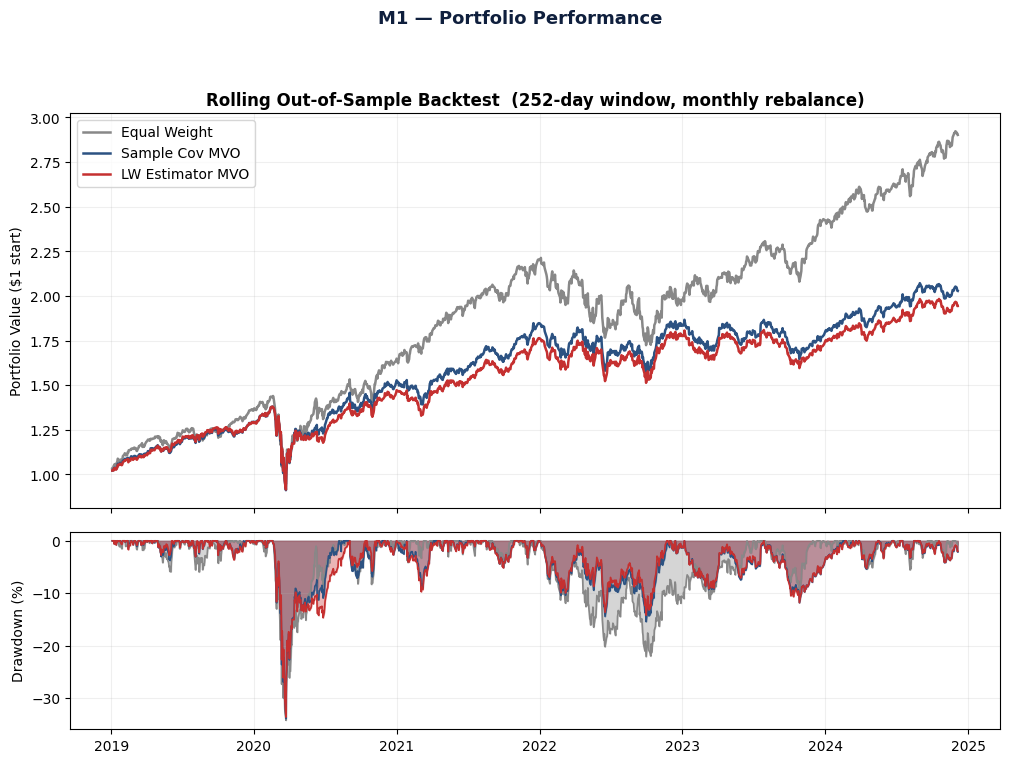

,Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Max Drawdown (%),Calmar Ratio
Equal Weight,20.00,19.92,1.004,-34.27,0.584
Sample Cov MVO,13.44,17.24,0.779,-33.96,0.396
LW Estimator MVO,12.68,16.99,0.746,-33.67,0.377


In [5]:
# ── §6  Visual 3 — Backtest Results ────────────────────────────────────────

C = {
    'Equal Weight':    '#888888',
    'Sample Cov MVO':  '#2c5282',
    'LW Estimator MVO':'#c53030',
}

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.08})

# Panel 1: cumulative wealth
for k in pv_df.columns:
    axes[0].plot(pv_df.index, pv_df[k], label=k, color=C[k], lw=1.8)
axes[0].set_ylabel('Portfolio Value ($1 start)')
axes[0].set_title('Rolling Out-of-Sample Backtest  (252-day window, monthly rebalance)',
                  fontweight='bold')
axes[0].legend(loc='upper left', fontsize=10)
axes[0].grid(True, alpha=0.2)

# Panel 2: drawdown
for k in dd_df.columns:
    axes[1].fill_between(dd_df.index, dd_df[k] * 100, 0,
                         alpha=0.35, color=C[k])
    axes[1].plot(dd_df.index, dd_df[k] * 100, color=C[k], lw=1.2, label=k)
axes[1].set_ylabel('Drawdown (%)')
axes[1].set_xlabel('')
axes[1].grid(True, alpha=0.2)

plt.suptitle('M1 — Portfolio Performance', fontsize=13, fontweight='bold',
             color='#0f1f3d', y=1.01)
plt.tight_layout()
plt.savefig('figures/m1_backtest.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Metrics table ──────────────────────────────────────────────────────────
def metrics(ret_series, label):
    ar   = ret_series.mean() * 252
    av   = ret_series.std()  * np.sqrt(252)
    sr   = ar / av if av > 0 else 0
    maxdd = drawdown((1 + ret_series).cumprod()).min()
    calmar = ar / abs(maxdd) if maxdd < 0 else np.nan
    return {
        'Ann. Return (%)':    round(ar  * 100, 2),
        'Ann. Volatility (%)':round(av  * 100, 2),
        'Sharpe Ratio':       round(sr,         3),
        'Max Drawdown (%)':   round(maxdd * 100, 2),
        'Calmar Ratio':       round(calmar,      3),
    }

results = pd.DataFrame({k: metrics(ret_df[k], k) for k in ret_df.columns}).T
display(results)


## Interpretation

Ledoit-Wolf is not trying to invent a new view of the market. It keeps the same broad structure as sample covariance, but removes enough noise to make optimization less fragile.

The improvements are modest but consistent: lower sensitivity to tiny, noisy eigenvalues, better numerical stability in the optimizer, and slightly better drawdown behavior in the backtest. The shrinkage intensity adapts automatically to the data, so there's no manual tuning involved.

For comparison with the other modules: LW is simpler and smoother than RMT (M2), which is more aggressive about cleaning the spectrum. It's data-driven with fewer structural assumptions than the factor models (M3), which impose economic structure. And it's static per rebalance window, unlike DCC-GARCH (M4) which is designed to adapt faster through time.

If you want a stable default baseline before moving to more specialized estimators, Ledoit-Wolf is usually the right starting point.